# Red Neuronal Convolucional

## Base de datos: CIFAR-10

In [1]:
import numpy as np

from keras.layers import Input, Flatten, Dense, Conv2D, BatchNormalization, LeakyReLU, Dropout, Activation
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import keras.backend as K 

from keras.datasets import cifar10

2025-01-27 00:37:53.525029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-27 00:37:53.540792: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-27 00:37:53.545360: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-27 00:37:53.558285: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-27 00:37:54.465039: W tensorflow/compiler/tf2

In [2]:
import pickle
import os

def load_cifar10_batch(file):
    with open(file, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        X = dict[b'data']
        Y = dict[b'labels']
        X = X.reshape(len(X), 3, 32, 32).transpose(0, 2, 3, 1)
        Y = np.array(Y)
        return X, Y

def load_cifar10(data_dir):
    x_train = []
    y_train = []
    # Cargar los lotes de datos de entrenamiento
    for i in range(1, 6):
        file = os.path.join(data_dir, f'data_batch_{i}')
        X, Y = load_cifar10_batch(file)
        x_train.append(X)
        y_train.append(Y)
    x_train = np.concatenate(x_train)
    y_train = np.concatenate(y_train)
    
    # Cargar los datos de prueba
    x_test, y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))
    
    return (x_train, y_train), (x_test, y_test)

# Especifica la ruta donde descomprimiste CIFAR-10
#cifar10_path = './datasets/cifar-10-batches-py/'  # Cambia esto a tu ruta local
cifar10_path = '/home/edgarrt/Files/Datasets/cifar-10-batches-py/'

# Cargar los datos desde la carpeta local
(x_train, y_train), (x_test, y_test) = load_cifar10(cifar10_path)

print("Datos de entrenamiento:", x_train.shape, y_train.shape)
print("Datos de prueba:", x_test.shape, y_test.shape)

Datos de entrenamiento: (50000, 32, 32, 3) (50000,)
Datos de prueba: (10000, 32, 32, 3) (10000,)


In [3]:
# Datos

NUM_CLASSES = 10

#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print(y_test[0])

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [4]:
# Arquitectura 01

input_layer = Input(shape=(32,32,3))

conv_layer_1 = Conv2D(
    filters = 32
    , kernel_size = (3,3)
    , strides = 2
    , padding = 'same'
    )(input_layer)

conv_layer_2 = Conv2D(
    filters = 64
    , kernel_size = (3,3)
    , strides = 2
    , padding = 'same'
    )(conv_layer_1)

conv_layer_3 = Conv2D(64,kernel_size=(3,3), strides=1, padding='same')(conv_layer_2)

conv_layer_4 = Conv2D(64,kernel_size=(3,3), strides=1, padding='same')(conv_layer_3)

flatten_layer = Flatten()(conv_layer_4)

output_layer = Dense(units=10, activation = 'softmax')(flatten_layer)

model = Model(input_layer, output_layer)

model.summary()

I0000 00:00:1737956317.953580      68 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-27 00:38:38.278660: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,218 (524.29 KB)

 Trainable params: 134,218 (524.29 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento

In [6]:
opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

model.fit(x_train
          , y_train
          , batch_size = 128
          , epochs=10
          , shuffle = True
          , validation_data = (x_test, y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3181 - loss: 1.9120 - val_accuracy: 0.3997 - val_loss: 1.7478
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4090 - loss: 1.7324 - val_accuracy: 0.4088 - val_loss: 1.7227
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.4218 - loss: 1.7032 - val_accuracy: 0.4048 - val_loss: 1.7266
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.4228 - loss: 1.6969 - val_accuracy: 0.4044 - val_loss: 1.7240
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.4231 - loss: 1.6927 - val_accuracy: 0.4070 - val_loss: 1.7273
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.4283 - loss: 1.6805 - val_accuracy: 0.4060 - val_loss: 1.7255
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4308 - loss: 1.6784 - val_accuracy: 0.4036 - val_loss: 1.7244
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4347 - loss: 1.6653 - 

# Analisis de resultados

In [8]:
model.evaluate(x_test, y_test, batch_size=1000)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.4023 - loss: 1.7289


[1.7319527864456177, 0.39879998564720154]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


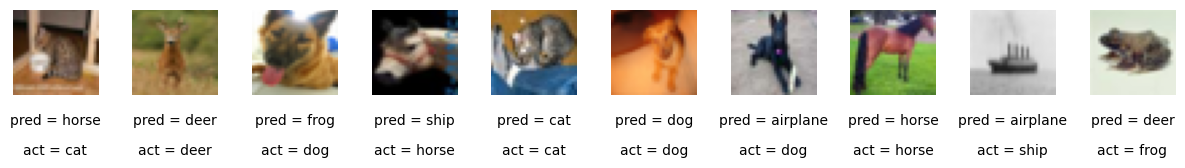

In [7]:
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

preds = model.predict(x_test)
preds_single = CLASSES[np.argmax(preds, axis = -1)]
actual_single = CLASSES[np.argmax(y_test, axis = -1)]

import matplotlib.pyplot as plt

n_to_show = 10
indices = np.random.choice(range(len(x_test)), n_to_show)

fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    img = x_test[idx]
    ax = fig.add_subplot(1, n_to_show, i+1)
    ax.axis('off')
    ax.text(0.5, -0.35, 'pred = ' + str(preds_single[idx]), fontsize=10, ha='center', transform=ax.transAxes) 
    ax.text(0.5, -0.7, 'act = ' + str(actual_single[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.imshow(img)